# Random Forest Regression: LAEI 2019 NOx Emissions

This notebook follows the general workflow of the supplied regression example, but it uses a **Random Forest Regressor** to predict `NOx_total_2019` from road traffic, speed, road length and road-classification variables in `laei2019_model_data.csv`.

The workflow covers data inspection, feature selection, train/test splitting, preprocessing, a mean baseline, Random Forest training, regression metrics, diagnostic plots, feature importance and error analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
TEST_SIZE = 0.20

## 1. Load and inspect the dataset

The CSV file should be in the same folder as this notebook. The initial checks show its dimensions, sample records, column types, missing values and duplicate road-link identifiers.

In [2]:
DATA_FILE = Path("laei2019_model_data.csv")

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"{DATA_FILE} was not found. Put the CSV file in the same folder as the notebook."
    )

df = pd.read_csv(DATA_FILE)

print("Dataset shape:", df.shape)
print()
print("First five rows:")
display(df.head())

print()
print("Data types:")
display(df.dtypes.to_frame("Data type"))

print()
print("Columns with the most missing values:")
display(df.isna().sum().sort_values(ascending=False).head(10).to_frame("Missing values"))

print()
print("Duplicate TOID values:", df["TOID"].duplicated().sum())
print("Number of boroughs:", df["Borough"].nunique())
print("Number of road classifications:", df["Road Classification"].nunique())

Dataset shape: (66962, 25)

First five rows:


,TOID,Borough,NOx_total_2019,AADT Motorcycle,AADT Taxi,AADT Petrol Car,AADT Diesel Car,AADT Electric Car,AADT Petrol PHV,AADT Diesel PHV,AADT Electric PHV,AADT Petrol LGV,AADT Diesel LGV,AADT Electric LGV,AADT 2019 - HGVs - Rigid - 2 Axles,AADT 2019 - HGVs - Rigid - 3 Axles,AADT 2019 - HGVs - Rigid - 4 or more Axles,AADT 2019 - HGVs - Articulated - 3 to 4 Axles,AADT 2019 - HGVs - Articulated - 5 Axles,AADT 2019 - HGVs - Articulated - 6 Axles,AADT 2019 - Buses,AADT 2019 - Coaches,Speed (km/hr) - Except Buses,Link Length (m),Road Classification
0,osgb4000000030337102,Bromley,0.197933,242.0,118.0,6396.0,4420.0,38.0,126.0,104.0,2.0,22.0,2510.0,6.0,95.0,14.0,30.0,6.0,13.0,36.0,324.0,197.0,13.0,54,A Road
1,osgb4000000030221346,Brent,0.294039,405.0,148.0,10718.0,7407.0,63.0,318.0,262.0,4.0,25.0,2873.0,6.0,449.0,67.0,143.0,27.0,59.0,169.0,808.0,270.0,15.0,47,A Road
2,osgb4000000030365896,Barking and Dagenham,0.237709,364.0,174.0,9468.0,6544.0,56.0,310.0,255.0,4.0,27.0,3145.0,7.0,563.0,84.0,180.0,34.0,74.0,212.0,213.0,80.0,13.0,39,A Road
3,osgb4000000030409722,Hillingdon,0.044987,137.0,40.0,3978.0,2749.0,24.0,136.0,112.0,2.0,6.0,693.0,2.0,82.0,12.0,26.0,5.0,11.0,31.0,67.0,110.0,14.0,24,A Road
4,osgb4000000030132840,Hounslow,0.731842,416.0,412.0,10928.0,7552.0,65.0,435.0,358.0,6.0,30.0,3437.0,8.0,470.0,70.0,150.0,29.0,62.0,177.0,99.0,215.0,44.0,194,A Road



Data types:


,Data type
TOID,object
Borough,object
NOx_total_2019,float64
AADT Motorcycle,float64
AADT Taxi,float64
AADT Petrol Car,float64
AADT Diesel Car,float64
AADT Electric Car,float64
AADT Petrol PHV,float64
AADT Diesel PHV,float64



Columns with the most missing values:


,Missing values
TOID,0
Borough,0
NOx_total_2019,0
AADT Motorcycle,0
AADT Taxi,0
AADT Petrol Car,0
AADT Diesel Car,0
AADT Electric Car,0
AADT Petrol PHV,0
AADT Diesel PHV,0



Duplicate TOID values: 0
Number of boroughs: 33
Number of road classifications: 7


Target variable summary:


,count,mean,std,min,25%,50%,75%,max
NOx_total_2019,66962.0,0.196363,0.637651,0.0,0.029843,0.078793,0.192699,40.063259


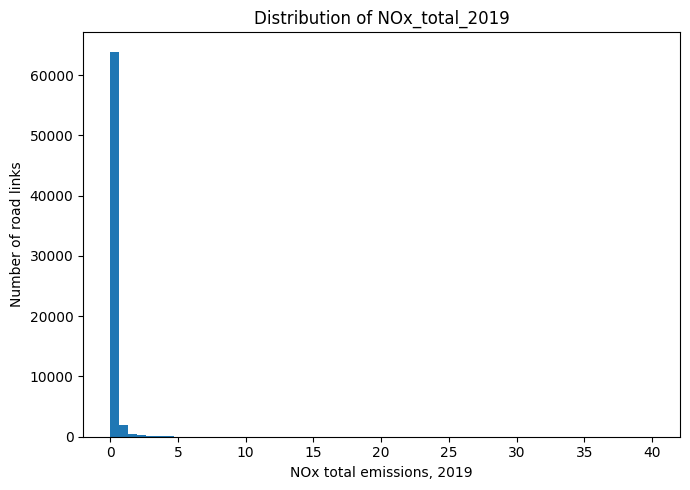

In [3]:
print("Target variable summary:")
display(df["NOx_total_2019"].describe().to_frame().T)

plt.figure(figsize=(7, 5))
plt.hist(df["NOx_total_2019"], bins=60)
plt.xlabel("NOx total emissions, 2019")
plt.ylabel("Number of road links")
plt.title("Distribution of NOx_total_2019")
plt.tight_layout()
plt.show()

The target distribution is strongly right-skewed: most road links have relatively low emissions, while a small number have much higher values. This makes MAE and RMSE useful together because RMSE penalises the largest prediction errors more strongly.

## 2. Define the predictors and target

`TOID` is a road-link identifier and is not used as a predictor. `Borough` is also excluded to keep the feature set consistent with the supplied example. The target is `NOx_total_2019`. `Road Classification` is categorical; all remaining predictors are numeric.

In [4]:
X = df.drop(columns=["TOID", "Borough", "NOx_total_2019"])
y = df["NOx_total_2019"]

categorical_features = ["Road Classification"]
numeric_features = [
    column for column in X.columns
    if column not in categorical_features
]

print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("Number of numeric features:", len(numeric_features))
print("Categorical features:", categorical_features)

X shape: (66962, 22)
y shape: (66962,)

Number of numeric features: 21
Categorical features: ['Road Classification']


## 3. Split the data and build the preprocessing pipeline

The same random seed is used throughout so that the results are reproducible. Numeric values are median-imputed and the road classification is one-hot encoded. Scaling is not required for Random Forest because tree splits are not based on feature magnitude.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 53569
Testing rows: 13393


In [6]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ],
    verbose_feature_names_out=False
)

## 4. Mean baseline

The mean baseline predicts the average training-set NOx value for every test record. A useful machine-learning model should substantially outperform this reference.

In [7]:
dummy_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

dummy_model.fit(X_train, y_train)
dummy_predictions = dummy_model.predict(X_test)

dummy_mae = mean_absolute_error(y_test, dummy_predictions)
dummy_rmse = np.sqrt(mean_squared_error(y_test, dummy_predictions))
dummy_r2 = r2_score(y_test, dummy_predictions)

print("Mean Baseline")
print("MAE:", dummy_mae)
print("RMSE:", dummy_rmse)
print("R2:", dummy_r2)

Mean Baseline
MAE: 0.18669178758667473
RMSE: 0.4446942032741145
R2: -0.001274191355049581


## 5. Random Forest Regressor

The Random Forest combines predictions from many decision trees. `min_samples_leaf=2` provides mild regularisation, while `max_features=0.70` introduces variation among the trees. `n_jobs=-1` allows Scikit-Learn to use the available CPU cores.

In [8]:
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        min_samples_leaf=2,
        max_features=0.70,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)
rf_train_predictions = random_forest_model.predict(X_train)

In [9]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)
rf_train_r2 = r2_score(y_train, rf_train_predictions)

print("Random Forest Regressor")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)
print("Train R2:", rf_train_r2)
print("Negative test predictions:", int((rf_predictions < 0).sum()))

Random Forest Regressor
MAE: 0.016671914904674522
RMSE: 0.06295624539092133
R2: 0.9799318321699911
Train R2: 0.9934296651970927
Negative test predictions: 0


## 6. Compare the baseline and Random Forest

Lower MAE and RMSE values are better. R2 values closer to 1 indicate that the model explains more of the variation in emissions. The train/test R2 comparison helps reveal whether the Random Forest is overfitting.

In [10]:
results = pd.DataFrame({
    "Model": ["Mean Baseline", "Random Forest Regressor"],
    "MAE": [dummy_mae, rf_mae],
    "RMSE": [dummy_rmse, rf_rmse],
    "R2": [dummy_r2, rf_r2]
})

results["RMSE improvement vs baseline (%)"] = [
    0.0,
    ((dummy_rmse - rf_rmse) / dummy_rmse) * 100
]

display(results.round(6))

print("Random Forest train R2:", round(rf_train_r2, 6))
print("Random Forest test R2:", round(rf_r2, 6))

,Model,MAE,RMSE,R2,RMSE improvement vs baseline (%)
0,Mean Baseline,0.186692,0.444694,-0.001274,0.000000
1,Random Forest Regressor,0.016672,0.062956,0.979932,85.842801


Random Forest train R2: 0.99343
Random Forest test R2: 0.979932


## 7. Actual versus predicted values

A perfect model would place all points on the dashed 45-degree line.

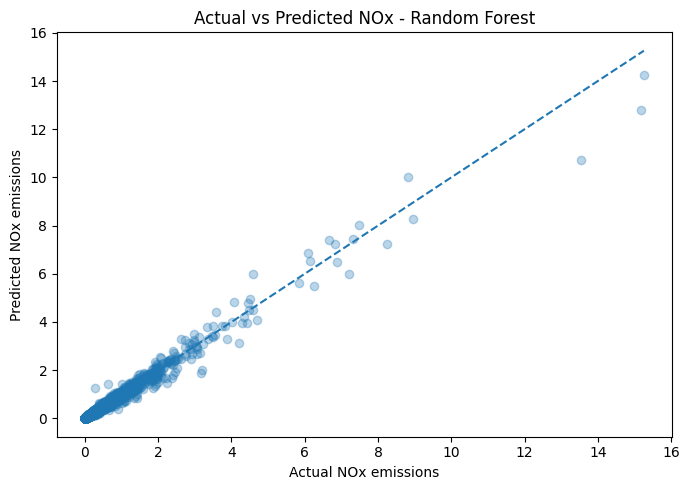

In [11]:
plot_min = min(y_test.min(), rf_predictions.min())
plot_max = max(y_test.max(), rf_predictions.max())

plt.figure(figsize=(7, 5))
plt.scatter(y_test, rf_predictions, alpha=0.30)
plt.plot([plot_min, plot_max], [plot_min, plot_max], linestyle="--")
plt.xlabel("Actual NOx emissions")
plt.ylabel("Predicted NOx emissions")
plt.title("Actual vs Predicted NOx - Random Forest")
plt.tight_layout()
plt.savefig("random_forest_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Residual analysis

Residuals are calculated as actual minus predicted emissions. A well-behaved model should have residuals distributed around zero without a strong pattern.

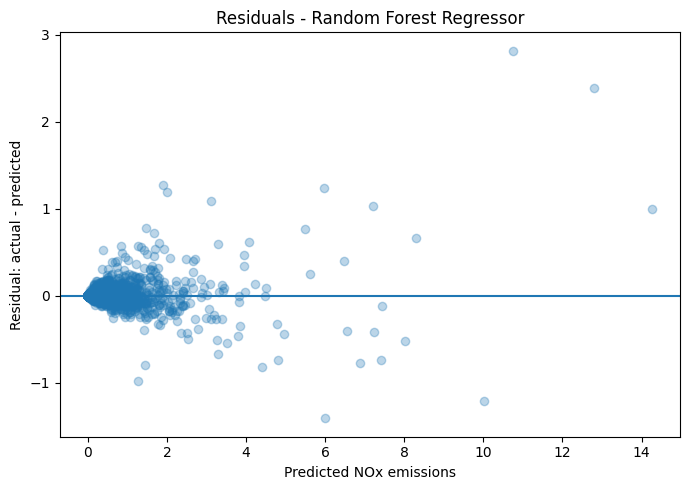

In [12]:
rf_residuals = y_test.to_numpy() - rf_predictions

plt.figure(figsize=(7, 5))
plt.scatter(rf_predictions, rf_residuals, alpha=0.30)
plt.axhline(0)
plt.xlabel("Predicted NOx emissions")
plt.ylabel("Residual: actual - predicted")
plt.title("Residuals - Random Forest Regressor")
plt.tight_layout()
plt.savefig("random_forest_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Random Forest feature importance

The importance scores show which transformed variables were used most strongly by the forest to reduce prediction error. They indicate predictive usefulness, not causation.

Top 15 features:


,Feature,Importance
0,Link Length (m),0.567036
1,AADT Diesel LGV,0.089088
2,AADT 2019 - HGVs - Articulated - 5 Axles,0.079980
3,AADT 2019 - HGVs - Articulated - 6 Axles,0.074178
4,AADT 2019 - HGVs - Articulated - 3 to 4 Axles,0.063992
5,AADT Petrol LGV,0.026876
6,AADT Diesel Car,0.020733
7,AADT Petrol Car,0.014425
8,AADT Electric Car,0.012498
9,Speed (km/hr) - Except Buses,0.008604


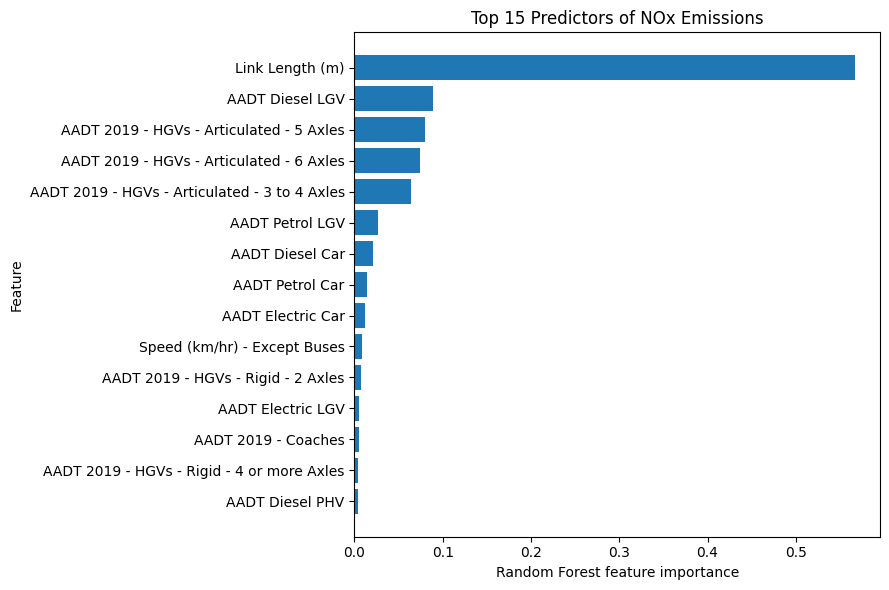

In [13]:
fitted_preprocessor = random_forest_model.named_steps["preprocessor"]
fitted_forest = random_forest_model.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": fitted_forest.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Top 15 features:")
display(feature_importance.head(15))

plot_importance = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(9, 6))
plt.barh(plot_importance["Feature"], plot_importance["Importance"])
plt.xlabel("Random Forest feature importance")
plt.ylabel("Feature")
plt.title("Top 15 Predictors of NOx Emissions")
plt.tight_layout()
plt.savefig("random_forest_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Inspect the largest prediction errors

The table below identifies test-set road links for which the model's prediction differs most from the recorded NOx value.

In [14]:
error_df = df.loc[
    X_test.index,
    ["TOID", "Borough", "Road Classification", "NOx_total_2019"]
].copy()

error_df = error_df.rename(columns={"NOx_total_2019": "Actual_NOx"})
error_df["Predicted_NOx"] = rf_predictions
error_df["Residual"] = error_df["Actual_NOx"] - error_df["Predicted_NOx"]
error_df["Absolute_Error"] = error_df["Residual"].abs()

print("Ten largest absolute errors:")
display(
    error_df
    .sort_values("Absolute_Error", ascending=False)
    .head(10)
)

Ten largest absolute errors:


,TOID,Borough,Road Classification,Actual_NOx,Predicted_NOx,Residual,Absolute_Error
39826,osgb4000000030076251,Hillingdon,M4,13.553714,10.738477,2.815237,2.815237
40038,osgb4000000030076496,Redbridge,M11,15.186764,12.804046,2.382717,2.382717
273,osgb4000000030076494,Redbridge,A Road,4.589611,6.001301,-1.411689,1.411689
5970,osgb4000000030081716,Hounslow,A Road,3.173313,1.902053,1.271260,1.271260
1059,osgb4000000030082844,Barking and Dagenham,A Road,7.214500,5.975946,1.238553,1.238553
7567,osgb4000000030074774,Hillingdon,A Road,8.814571,10.024958,-1.210387,1.210387
17641,osgb4000000030100470,Greenwich,A Road,3.194360,2.008944,1.185417,1.185417
199,osgb4000000030082839,Barking and Dagenham,A Road,4.199947,3.107076,1.092871,1.092871
40139,osgb4000000030094289,Hillingdon,M25,8.241761,7.216686,1.025075,1.025075
39841,osgb4000000030076337,Barnet,M1,15.259477,14.258611,1.000866,1.000866


## 11. Save the results

The metrics, test predictions and feature-importance table are saved as CSV files. The diagnostic charts have already been saved as PNG files.

In [15]:
results.to_csv("random_forest_regression_results.csv", index=False)
error_df.to_csv("random_forest_test_predictions.csv", index=False)
feature_importance.to_csv("random_forest_feature_importance.csv", index=False)

print("Saved files:")
print("- random_forest_regression_results.csv")
print("- random_forest_test_predictions.csv")
print("- random_forest_feature_importance.csv")
print("- random_forest_actual_vs_predicted.png")
print("- random_forest_residuals.png")
print("- random_forest_feature_importance.png")

Saved files:
- random_forest_regression_results.csv
- random_forest_test_predictions.csv
- random_forest_feature_importance.csv
- random_forest_actual_vs_predicted.png
- random_forest_residuals.png
- random_forest_feature_importance.png


## Conclusion

The mean baseline provides a minimum reference level, while the Random Forest captures nonlinear relationships and interactions among traffic-flow, speed, link-length and road-classification variables. Use the executed metric table, diagnostic plots and feature-importance results when writing the performance discussion for the assignment.

This notebook demonstrates **one** modelling technique. The assignment still requires at least two additional machine-learning algorithms to be described, developed and compared with the Random Forest.